In [2]:
## Imports

import iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import iris.plot as iplt
import iris.quickplot as qplt
import iris.analysis.cartography
import iris.analysis
import aeolus
import aeolus.calc
import aeolus.coord
import matplotlib.colors as mcolors


import warnings
warnings.filterwarnings("ignore")


In [3]:
## Loading the files for the six different surface pressures

point_25 = iris.load('/data/cluster4/jj22956/pr92_thunderstruck_files/thunderstruck-hab1_0p25bar-pr92-time-ave-prof.nc')
point_5 = iris.load('/data/cluster4/jj22956/pr92_thunderstruck_files/thunderstruck-hab1_0p5bar-pr92-time-ave-prof.nc')
one = iris.load('/data/cluster4/jj22956/pr92_thunderstruck_files/thunderstruck-hab1_1bar-pr92-time-ave-prof.nc')
two = iris.load('/data/cluster4/jj22956/pr92_thunderstruck_files/thunderstruck-hab1_2bar-pr92-time-ave-prof.nc')
four = iris.load('/data/cluster4/jj22956/pr92_thunderstruck_files/thunderstruck-hab1_4bar-pr92-time-ave-prof.nc')
ten = iris.load('/data/cluster4/jj22956/pr92_thunderstruck_files/thunderstruck-hab1_10bar-pr92-time-ave-prof.nc')


## Surface pressures, unit: bar
point_25_surface_pressure_bar, point_5_surface_pressure_bar, one_surface_pressure_bar, two_surface_pressure_bar, four_surface_pressure_bar, ten_surface_pressure_bar , ISA_surface_pressure_bar = 0.25, 0.5, 1, 2, 4, 10, 1


In [4]:
## Extract air pressure and temperature cubes and reduce to their temporal means (from 4D to 3D)
## Average over the dayside (from 3D to 2D)
## Retrieve and flatten the data points for air temperature and air pressure

def tempfunction(cube):
    air_temperature = cube.extract_cube('m01s16i004')
    airtemp_mean = air_temperature.collapsed(['longitude', 'latitude'], iris.analysis.MEAN)
    AIRTEMP_FLAT = (airtemp_mean.data).flatten()
    return AIRTEMP_FLAT

def pressurefunction(cube):
    air_pressure = cube.extract_cube('m01s00i408')
    airpressure_mean = air_pressure.collapsed(['longitude', 'latitude'], iris.analysis.MEAN)
    AIRPRESSURE_FLAT = (airpressure_mean.data).flatten()
    return AIRPRESSURE_FLAT[:63]


In [5]:
## Air temperature
point_25_temps = tempfunction(point_25)
point_5_temps = tempfunction(point_5)
one_temps = tempfunction(one)
two_temps = tempfunction(two)
four_temps = tempfunction(four)
ten_temps = tempfunction(ten)

## Air pressure
point_25_pressures = pressurefunction(point_25)
point_5_pressures = pressurefunction(point_5)
one_pressures = pressurefunction(one)
two_pressures = pressurefunction(two)
four_pressures = pressurefunction(four)
ten_pressures = pressurefunction(ten)


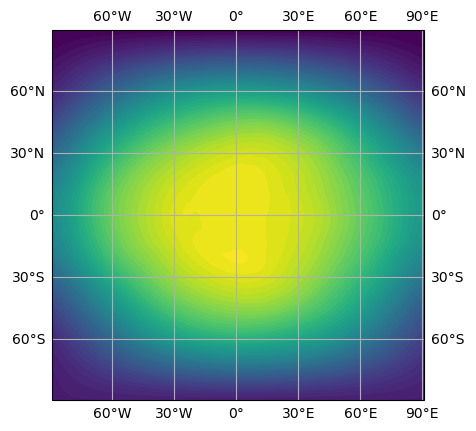

In [6]:
# one.extract_cube('m01s16i004')
iplt.contourf(aeolus.calc.stats.vertical_mean(one.extract_cube('m01s16i004')), 50)
plt.gca().gridlines(draw_labels=True)
plt.show()

In [7]:
## Getting sigma pressures
point_25_sigmas = (pressurefunction(point_25) / (point_25_surface_pressure_bar * 100000))
point_5_sigmas = (pressurefunction(point_5) / (point_5_surface_pressure_bar * 100000))
one_sigmas = (pressurefunction(one) / (one_surface_pressure_bar * 100000))
two_sigmas = (pressurefunction(two) / (two_surface_pressure_bar * 100000))
four_sigmas = (pressurefunction(four) / (four_surface_pressure_bar * 100000))
ten_sigmas = (pressurefunction(ten) / (ten_surface_pressure_bar * 100000))


## Option to use log_10(sigma), which scales directly with height
point_25_log10sigmas = np.log10(pressurefunction(point_25) / (point_25_surface_pressure_bar * 100000))
point_5_log10sigmas = np.log10(pressurefunction(point_5) / (point_5_surface_pressure_bar * 100000))
one_log10sigmas = np.log10(pressurefunction(one) / (one_surface_pressure_bar * 100000))
two_log10sigmas = np.log10(pressurefunction(two) / (two_surface_pressure_bar * 100000))
four_log10sigmas = np.log10(pressurefunction(four) / (four_surface_pressure_bar * 100000))
ten_log10sigmas = np.log10(pressurefunction(ten) / (ten_surface_pressure_bar * 100000))

In [8]:
## ISA
# ISA_sigmas = np.loadtxt('/data/cluster4/jj22956/pr92_thunderstruck_files/ISA_sigmas_no_troposphere.txt')
# ISA_temps = np.loadtxt('/data/cluster4/jj22956/pr92_thunderstruck_files/ISA_temps_no_troposphere.txt')

In [9]:
## Averaging over all the profiles, disregarding the 10 bar case as we later find it doesn't work with the simulation

# mean_temps = np.mean((point_25_temps, point_5_temps, one_temps, two_temps, four_temps, ten_temps), axis=0)
mean_temps = np.mean((point_25_temps, point_5_temps, one_temps, two_temps, four_temps), axis=0)

# mean_sigmas = np.mean((point_25_sigmas, point_5_sigmas, one_sigmas, two_sigmas, four_sigmas, ten_sigmas), axis=0)
mean_sigmas = np.mean((point_25_sigmas, point_5_sigmas, one_sigmas, two_sigmas, four_sigmas), axis=0)

# mean_log10sigmas = np.mean((point_25_log10sigmas, point_5_log10sigmas, one_log10sigmas, two_log10sigmas, four_log10sigmas, ten_log10sigmas), axis=0)
mean_log10sigmas = np.mean((point_25_log10sigmas, point_5_log10sigmas, one_log10sigmas, two_log10sigmas, four_log10sigmas), axis=0)

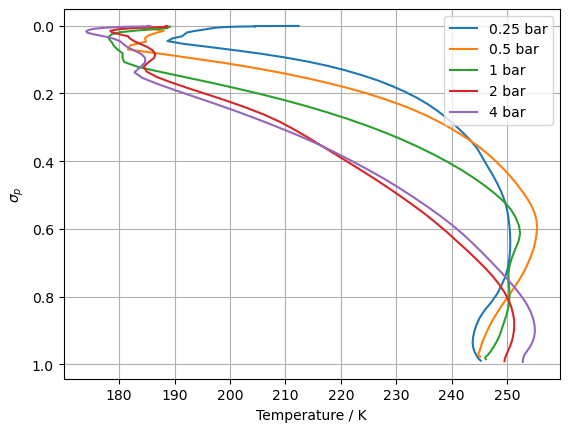

In [ ]:
## Regular sigma plot

plt.plot(point_25_temps, point_25_sigmas, label='0.25 bar')

plt.plot(point_5_temps, point_5_sigmas, label='0.5 bar') 

plt.plot(one_temps, one_sigmas, label='1 bar')

plt.plot(two_temps, two_sigmas, label='2 bar') 

plt.plot(four_temps, four_sigmas, label='4 bar') 

# plt.plot(ten_temps, ten_sigmas, label='10 bar') 

strat_low = - 1
strat_high = -2.25
plt.gca().invert_yaxis() # Get pressure going in the right direction on the axis
plt.xlabel('Temperature / K')
plt.ylabel(r'$\sigma_p$')
# plt.title('Air Temperature Profiles')
plt.legend(loc = 'upper right')
plt.grid()
plt.savefig('/data/cluster4/jj22956/lightning_figures/all_pr92_pressures_temp-sigma_profiles.pdf')
plt.show()

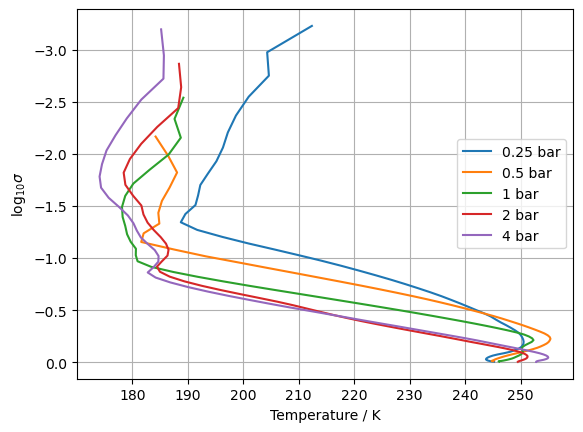

In [ ]:
## log_10 sigma plot (scales with altitude)

plt.plot(point_25_temps, point_25_log10sigmas, label='0.25 bar')

plt.plot(point_5_temps, point_5_log10sigmas, label='0.5 bar') 

plt.plot(one_temps, one_log10sigmas, label='1 bar')

plt.plot(two_temps, two_log10sigmas, label='2 bar') 

plt.plot(four_temps, four_log10sigmas, label='4 bar') 

# plt.plot(ten_temps, ten_log10sigmas, label='10 bar') 

strat_low = - 1
strat_high = -2.25
plt.gca().invert_yaxis() # Get pressure going in the right direction on the axis
plt.xlabel('Temperature / K')
plt.ylabel(r'log$_{10}\sigma$')
# plt.title('Air Temperature Profiles')
plt.legend(loc = 'right')
plt.grid()
plt.savefig('/data/cluster4/jj22956/lightning_figures/all_pr92_pressures_temp-log10sigma_profiles.pdf')
plt.show()

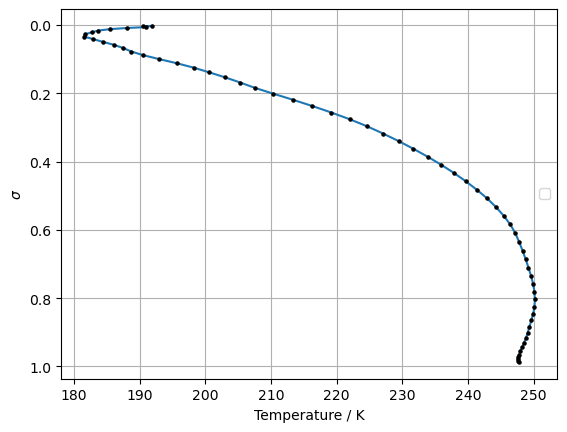

In [ ]:
## Averaged sigma-T plot over all surface pressures

plt.plot(mean_temps, mean_sigmas)
plt.scatter(mean_temps, mean_sigmas, s = 5, facecolor = 'black', zorder = 3)

plt.gca().invert_yaxis() # Get pressure going in the right direction on the axis
plt.xlabel('Temperature / K')
plt.ylabel(r'$\sigma$')
# plt.title('Air Temperature Profiles')
plt.legend(loc = 'right')
plt.grid()
plt.savefig('/data/cluster4/jj22956/lightning_figures/averaged_temp-sigma_profile.pdf')
plt.show()

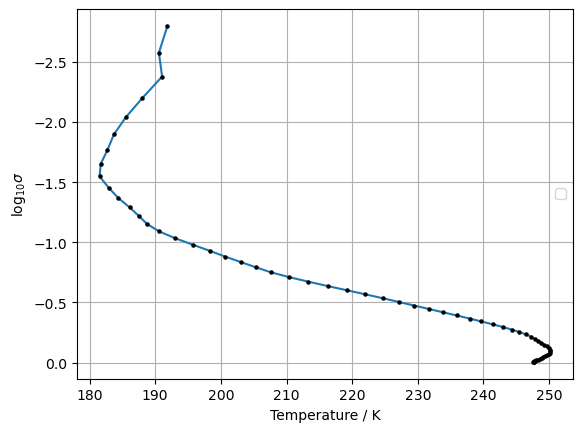

In [ ]:
## Averaged log10sigma-T plot over all surface pressures


plt.plot(mean_temps, mean_log10sigmas)
plt.scatter(mean_temps, mean_log10sigmas, s = 5, facecolor = 'black', zorder = 3)

plt.gca().invert_yaxis() # Get pressure going in the right direction on the axis
plt.xlabel('Temperature / K')
plt.ylabel(r'log$_{10}\sigma$')
# plt.title('Air Temperature Profiles')
plt.legend(loc = 'right')
plt.grid()
plt.savefig('/data/cluster4/jj22956/lightning_figures/averaged_temp-log10sigma_profile.pdf')
plt.show()

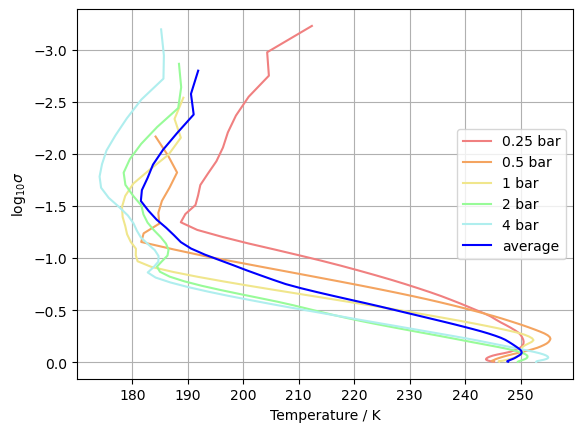

In [14]:
## Plotting the average alongside the other profiles (this is for log10(sigma))

plt.plot(point_25_temps, point_25_log10sigmas, label='0.25 bar', color='lightcoral')
plt.plot(point_5_temps, point_5_log10sigmas, label='0.5 bar', color='sandybrown') 
plt.plot(one_temps, one_log10sigmas, label='1 bar', color='khaki')
plt.plot(two_temps, two_log10sigmas, label='2 bar', color='palegreen') 
plt.plot(four_temps, four_log10sigmas, label='4 bar', color='paleturquoise') 
# plt.plot(ten_temps, ten_log10sigmas, label='10 bar', color='plum')

plt.plot(mean_temps, mean_log10sigmas, label='average', color='blue')

strat_low = - 1
strat_high = -2.25
plt.gca().invert_yaxis() # Get pressure going in the right direction on the axis
plt.xlabel('Temperature / K')
plt.ylabel(r'log$_{10}\sigma$')
# plt.title('Air Temperature Profiles')
plt.legend(loc = 'right')
plt.grid()
plt.savefig('/data/cluster4/jj22956/lightning_figures/pr92_temp_profile_plus_averaged.pdf')
plt.show()

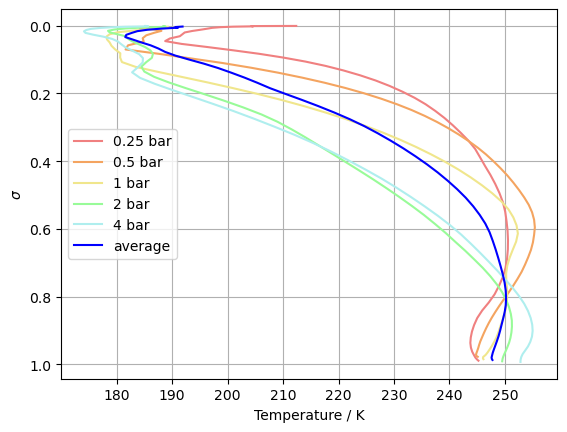

In [15]:
## Plotting the average alongside the other profiles (this is for regular sigma)

plt.plot(point_25_temps, point_25_sigmas, label='0.25 bar', color='lightcoral')
plt.plot(point_5_temps, point_5_sigmas, label='0.5 bar', color='sandybrown') 
plt.plot(one_temps, one_sigmas, label='1 bar', color='khaki')
plt.plot(two_temps, two_sigmas, label='2 bar', color='palegreen') 
plt.plot(four_temps, four_sigmas, label='4 bar', color='paleturquoise') 
# plt.plot(ten_temps, ten_sigmas, label='10 bar', color='plum')

plt.plot(mean_temps, mean_sigmas, label='average', color='blue')

strat_low = - 1
strat_high = -2.25
plt.gca().invert_yaxis() # Get pressure going in the right direction on the axis
plt.xlabel('Temperature / K')
plt.ylabel(r'$\sigma$')
# plt.title('Air Temperature Profiles')
plt.legend(loc = 'center left')
plt.grid()
plt.savefig('/data/cluster4/jj22956/lightning_figures/pr92__regular_sigma-temp_profile_plus_averaged.pdf')
plt.show()

In [16]:
## This is for finding where the troposphere/stratosphere/mesosphere layers start and end in the code (via indexing)
print('Stratosphere: ', np.array(np.where(mean_log10sigmas<-1.5))) 
print('Troposphere: ', np.array(np.where(mean_log10sigmas>-1.5)))
print(mean_temps[0], mean_temps[54], mean_log10sigmas[54], mean_log10sigmas[53], mean_sigmas[54], mean_sigmas[53])

Stratosphere:  [[54 55 56 57 58 59 60 61 62]]
Troposphere:  [[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
  24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
  48 49 50 51 52 53]]
247.75313 181.52821 -1.547810083478516 -1.4537655064658364 0.03352972216796875 0.04091296337890625


In [17]:
## Constraining the stratosphere data points (and mesosphere, needed to make the polynomial fit better)
## This is for log_10(sigma pressure), the same process fpr sigma pressure is further down

strat_log10sigmas = mean_log10sigmas[np.where(mean_log10sigmas<-1.4)]
strat_temps = mean_temps[np.where(mean_log10sigmas<-1.4)]

## This is for the stratosphere

log_strat_z = np.polyfit(strat_log10sigmas, strat_temps, 5)
log_stratfunction = np.poly1d(log_strat_z)

poly_strat_log10sigmas = np.linspace(-2.9, -1.5, 50)
poly_strat_temps = log_stratfunction(poly_strat_log10sigmas)

log_stratfunction

poly1d([  -35.06549465,  -354.22940277, -1390.99131988, -2643.34887897,
       -2428.00770975,  -679.7546571 ])

In [18]:
print(len(poly_strat_temps), len(poly_strat_log10sigmas))

50 50


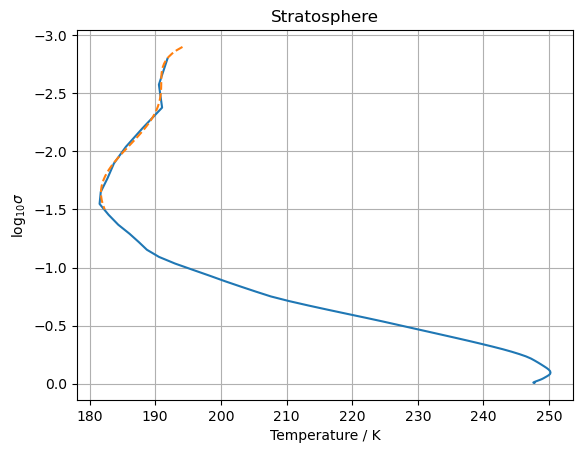

In [19]:
plt.plot(mean_temps, mean_log10sigmas, '-')
plt.plot(poly_strat_temps, poly_strat_log10sigmas, '--')
plt.gca().invert_yaxis() # Pressure decreases with height
plt.xlabel('Temperature / K')
plt.ylabel(r'log$_{10}\sigma$')
plt.title('Stratosphere')
# plt.xlim(100,300)
plt.grid()
plt.show()

In [20]:
# Testing the accuracy of the stratosphere and mesosphere polynomial fits by inputting pressures that cover the full atmosphere range

log10sigp = np.arange(-3, 0, 0.01)
t = np.zeros(len(log10sigp))

def temp_log10sigma_strat(log10sigma_p):
    if log10sigma_p > -1.6: #Troposphere
        return 182
    elif log10sigma_p < -1.6: # Stratosphere and mesosphere
        # a0 = -30.43211282 
        # a1 = -326.74239476 
        # a2 = -1367.59054705 
        # a3 = -2781.44726859
        # a4 = -2749.10919324
        # a5 = -876.66970866
        a0 = -35.06549465
        a1 = -354.22940277
        a2  = -1390.99131988
        a3 = -2643.34887897
        a4 = -2428.00770975
        a5 = -679.7546571
        return a0 * log10sigma_p**5 + a1 * log10sigma_p**4 + a2 * log10sigma_p**3 + a3 * log10sigma_p**2 + a4 * log10sigma_p + a5    
    
for i in range(len(log10sigp)):
    log10sigmapressure = log10sigp[i]
    t[i] = temp_log10sigma_strat(log10sigmapressure)

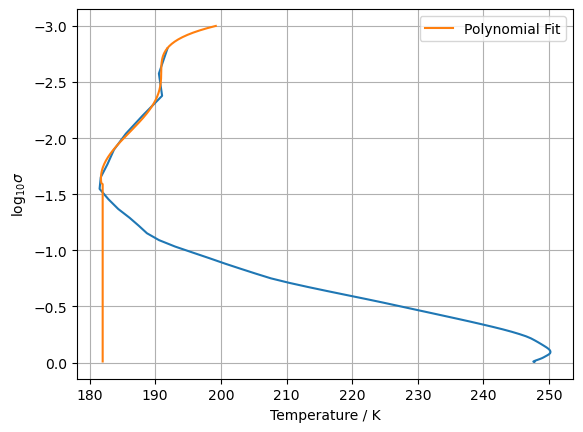

In [21]:
plt.plot(mean_temps, mean_log10sigmas)
plt.plot(t, log10sigp, label='Polynomial Fit') # Plot produced by the double-polynomial function
# strat_high = -2.5
# strat_low = -1.6
# plt.axhspan(strat_low, strat_high, color='yellow', alpha=0.75, lw=0) # Shade the area representing the stratosphere
plt.gca().invert_yaxis() # Get pressure going in the right direction on the axis
plt.xlabel('Temperature / K')
plt.ylabel(r'log$_{10}\sigma$')
# plt.title('TRAPPIST-1e Air Temperature Profile')
plt.legend()
plt.grid()
plt.show()

In [22]:
## A repeat of the construction of the polynomial using sigma pressure

strat_sigmas = mean_sigmas[np.where(mean_log10sigmas<0.03)]
strat_temps = mean_temps[np.where(mean_log10sigmas<0.03)]

## This is for the stratosphere

strat_z = np.polyfit(strat_sigmas, strat_temps, 13)
stratfunction = np.poly1d(strat_z)

poly_strat_sigmas = np.linspace(10**(-1.5), 10**(-2.9), 50)
poly_strat_temps = stratfunction(poly_strat_sigmas)

stratfunction

poly1d([-4.85041400e+06,  3.44525262e+07, -1.09454817e+08,  2.05112060e+08,
       -2.51725930e+08,  2.12391143e+08, -1.25833479e+08,  5.25311360e+07,
       -1.52830243e+07,  3.01971914e+06, -3.87867573e+05,  3.00469800e+04,
       -1.04640598e+03,  1.94698709e+02])

In [23]:
print(len(poly_strat_temps), len(poly_strat_sigmas))

50 50


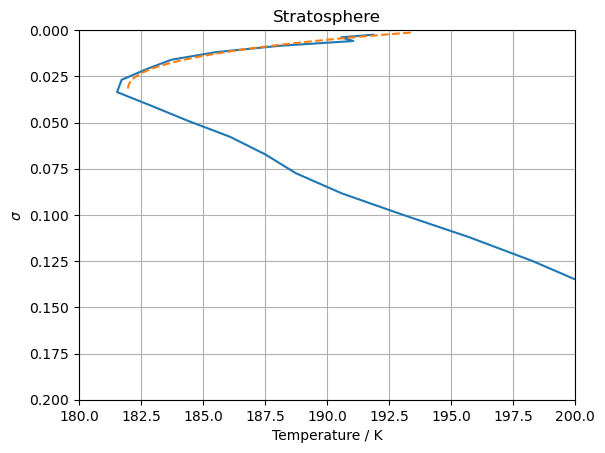

In [24]:
plt.plot(mean_temps, mean_sigmas, '-')
plt.plot(poly_strat_temps, poly_strat_sigmas, '--')
plt.gca().invert_yaxis() # Pressure decreases with height
plt.xlabel('Temperature / K')
plt.ylabel(r'$\sigma$')
plt.title('Stratosphere')
plt.xlim(180,200)
plt.ylim(0.2, 0.0)
plt.grid()
plt.show()

In [25]:
# Again, testing the accuracy of the stratosphere and mesosphere polynomial fits by inputting pressures that cover the full atmosphere range

sigp = np.arange(0, 1, 0.001)
tnew = np.zeros(len(sigp))

def temp_sigma_strat(sigma_p):
    if sigma_p > 10**(-1.6): #Troposphere
        return 181
    elif sigma_p < 10**(-1.6): # Stratosphere and mesosphere
        a0 = -5.48111151e+06  
        a1 = 3.84103783e+07 
        a2 = -1.20362802e+08  
        a3 = 2.22501586e+08
        a4 = -2.69539595e+08
        a5 = 2.24761457e+08 
        a6 = -1.31865881e+08  
        a7 = 5.46642089e+07
        a8 = -1.58446712e+07
        a9 = 3.12803842e+06
        a10 = -4.01281631e+05
        a11 = 3.07742872e+04
        a12 = -1.04320651e+03
        a13 = 1.92720864e+02
        return (a0 * sigma_p**13  +  a1 * sigma_p**12  + a2 * sigma_p**11  + a3 * sigma_p**10  + a4 * sigma_p**9  + 
                a5 * sigma_p**8  + a6 * sigma_p**7  + a7 * sigma_p**6  + a8 * sigma_p**5  + a9 * sigma_p**4  + 
                a10 * sigma_p**3  + a11 * sigma_p**2  + a12 * sigma_p  + a13)
    
for i in range(len(sigp)):
    sigmapressure = sigp[i]
    tnew[i] = temp_sigma_strat(sigmapressure)

In [26]:
# print(sigp)

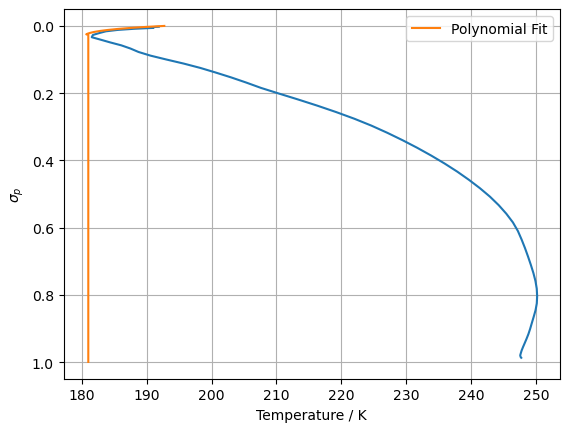

In [27]:
plt.plot(mean_temps, mean_sigmas)
plt.plot(tnew, sigp, label='Polynomial Fit') # Plot produced by the double-polynomial function
# strat_high = -2.5
# strat_low = -1.6
# plt.axhspan(strat_low, strat_high, color='yellow', alpha=0.75, lw=0) # Shade the area representing the stratosphere
plt.gca().invert_yaxis() # Get pressure going in the right direction on the axis
plt.xlabel('Temperature / K')
plt.ylabel(r'$\sigma_p$')
# plt.title('TRAPPIST-1e Air Temperature Profile')
plt.legend()
plt.grid()
plt.show()

In [28]:
surfacepressures = np.array([point_25_surface_pressure_bar, point_5_surface_pressure_bar, one_surface_pressure_bar, two_surface_pressure_bar, four_surface_pressure_bar, ten_surface_pressure_bar])
strat_temps = np.array([point_25_temps[49], point_5_temps[54], one_temps[48], two_temps[44], four_temps[41], ten_temps[51]])

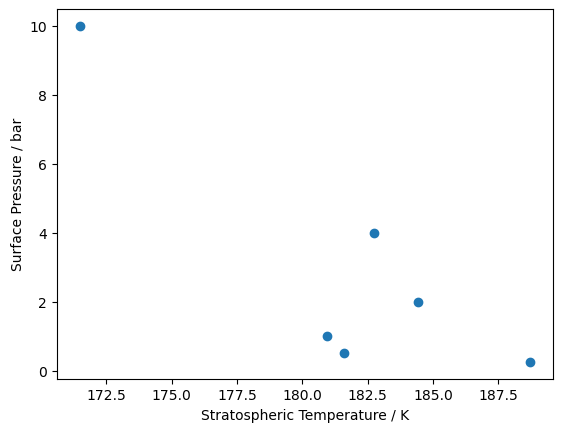

In [29]:
# plt.plot(surfacepressures, strat_temps)
plt.scatter(strat_temps, surfacepressures)
plt.xlabel('Stratospheric Temperature / K')
plt.ylabel('Surface Pressure / bar')
plt.show()

In [30]:
## Other

In [ ]:
## Loading the other pr92 files for the five different surface pressures that contains LFR

newpoint_25 = iris.load('/data/cluster4/jj22956/pr92_thunderstruck_files/other/thunderstruck-hab1_0p25bar-pr92.nc?download=1')
newpoint_5 = iris.load('/data/cluster4/jj22956/pr92_thunderstruck_files/other/thunderstruck-hab1_0p5bar-pr92.nc?download=1')
newone = iris.load('/data/cluster4/jj22956/pr92_thunderstruck_files/other/thunderstruck-hab1_1bar-pr92.nc?download=1')
newtwo = iris.load('/data/cluster4/jj22956/pr92_thunderstruck_files/other/thunderstruck-hab1_2bar-pr92.nc?download=1')
newfour = iris.load('/data/cluster4/jj22956/pr92_thunderstruck_files/other/thunderstruck-hab1_4bar-pr92.nc?download=1')


In [ ]:
## Functions to load the LFR and upward plume velocity cubes

def LFR(cube):
    LFR = cube.extract_cube('m01s21i104')
    LFR_mean = aeolus.calc.stats.time_mean(LFR)
    LFR_data = LFR_mean.data
    return LFR_data

def upwardvelocity(cube):
    velocity = cube.extract_cube('m01s00i150')
    velocity_timemean = aeolus.calc.stats.time_mean(velocity)
    # velocity_mean = velocity_timemean.extract(iris.Constraint(longitude = 0, latitude = 0))
    # return velocity_mean
    return velocity_timemean

In [33]:
point_25_LFR = LFR(newpoint_25)
point_5_LFR = LFR(newpoint_5)
one_LFR = LFR(newone)
two_LFR = LFR(newtwo)
four_LFR = LFR(newfour)